In [ ]:
import sys
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
from pathlib import Path
import requests
from PIL import Image

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
shared_folder = "Machine_learning_project/Data/Raw"

target_df = pd.read_csv(f"/content/drive/MyDrive/{shared_folder}/target.csv")
feature_df = pd.read_csv(f"/content/drive/MyDrive/{shared_folder}/listings.csv")
test_ids = np.load(f"/content/drive/MyDrive/{shared_folder}/test_ids.npy")
train_ids = np.load(f"/content/drive/MyDrive/{shared_folder}/train_ids.npy")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
feature_df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,6606,https://www.airbnb.com/rooms/6606,20250925032813,2025-09-25,city scrape,"Fab, private seattle urban cottage!","This tiny cottage is only 15x10, but it has ev...","A peaceful yet highly accessible neighborhood,...",https://a0.muscache.com/pictures/45742/21116d7...,14942,...,4.77,4.88,4.57,str-opli-19-002622,f,3,3,0,0,0.82
1,9419,https://www.airbnb.com/rooms/9419,20250925032813,2025-09-25,city scrape,Glorious sun room w/ memory foambed,This beautiful double room features sun filled...,"Lots of restaurants (see our guide book) bars,...",https://a0.muscache.com/pictures/56645186/e5fb...,30559,...,4.89,4.70,4.69,Exempt,f,10,0,10,0,1.19
2,9596,https://www.airbnb.com/rooms/9596,20250925032813,2025-09-25,previous scrape,"the down home , spacious, central and fab!","We are in a great neighborhood, quiet, full of...","if you arrive early for check in at 3, I reco...",https://a0.muscache.com/pictures/665252/102d18...,14942,...,4.66,4.91,4.56,STR -OPLI-19-002622,f,3,3,0,0,0.56
3,11012,https://www.airbnb.com/rooms/11012,20250925032813,2025-09-25,city scrape,"the orange house, quiet 'n central",NaN,NaN,https://a0.muscache.com/pictures/682034/54bc27...,14942,...,4.72,4.86,4.74,str-opli-19-002622,f,3,3,0,0,0.51
4,25002,https://www.airbnb.com/rooms/25002,20250925032813,2025-09-25,city scrape,Beautiful Private Spot in North Ballard,"-Great eating , Delancey, Fat Hen, 3 blocks aw...",Great walking neighborhood! We are in between...,https://a0.muscache.com/pictures/491561/cf5270...,102684,...,4.98,4.90,4.90,STR-OPLI-19-002617,t,1,1,0,0,6.06


In [ ]:
FEATURE_COLUMN   = "picture_url"   # column containing the image URLs
LABEL_COLUMN = "price"       # column used as the label

In [ ]:
def get_images(df):
  TIMEOUT = 10
  images = []
  for url in df[FEATURE_COLUMN]:
    try:
        r = requests.get(url, timeout=TIMEOUT, stream=True)
        r.raise_for_status()
        if r.headers.get("Content-Type", "").startswith("image/"):
            img = True
        else:
            img = False
    except Exception:
        img = False

    images.append(img)

  df["available"] = images
  return df

In [ ]:
listings_img_availability = get_images(feature_df)
listings_img_availability.to_csv('listings_image_availability.csv', index=False)

In [ ]:
#Creating the train and test datasets
available_ids = feature_df.loc[feature_df['available'], 'id']

X_train = feature_df[feature_df['id'].isin(train_ids) & feature_df['id'].isin(available_ids)][['picture_url']]
y_train = target_df[target_df['id'].isin(train_ids) & target_df['id'].isin(available_ids)][['log_price']]

x_test = feature_df[feature_df['id'].isin(test_ids) & feature_df['id'].isin(available_ids)][['picture_url']]
y_test = target_df[target_df['id'].isin(test_ids) & target_df['id'].isin(available_ids)][['log_price']]

In [ ]:
total_train = feature_df['id'].isin(train_ids).sum()
total_test = feature_df['id'].isin(test_ids).sum()

available_train = len(X_train)
available_test = len(x_test)

print(f"Train: {available_train} / {total_train} available ({available_train/total_train:.1%})")
print(f"Test:  {available_test} / {total_test} available ({available_test/total_test:.1%})")

Train: 4614 / 4926 available (93.7%)
Test:  1157 / 1232 available (93.9%)


In [ ]:
# Merge availability flag with price info
merged = feature_df[['id', 'available']].merge(target_df[['id', 'log_price']], on='id')

# Compare summary stats
print(merged.groupby('available')['log_price'].describe())

            count      mean       std       min       25%       50%       75%  \
available                                                                       
False       387.0  5.010987  0.637074  2.833213  4.644391  4.997212  5.375278   
True       5771.0  5.002346  0.574787  2.708050  4.653960  4.997212  5.337538   

                max  
available            
False      7.310550  
True       7.448334  


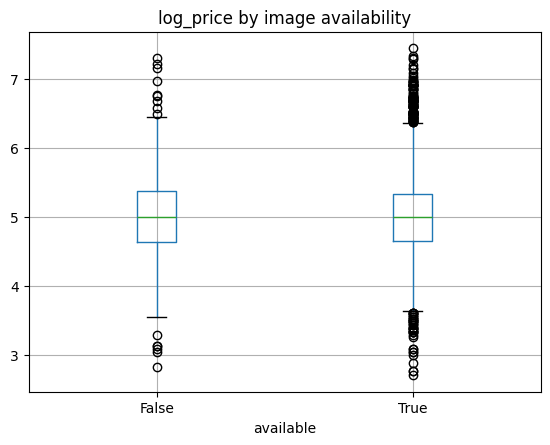

p-value: 0.9242


In [ ]:
merged.boxplot(column='log_price', by='available')
plt.title('log_price by image availability')
plt.suptitle('')
plt.show()

available_prices = merged[merged['available']]['log_price']
unavailable_prices = merged[~merged['available']]['log_price']

t_stat, p_value = stats.mannwhitneyu(available_prices, unavailable_prices)
print(f"p-value: {p_value:.4f}")
#if p>0.5 the missingness is just random so its better to drop it.